# Здравствуйте, дорогие организаторы!

Мы очень старались над решением и надеемся, что оно вам понравится

In [ ]:
import numpy as np
import pandas as pd
import random
from math import *
import copy
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from time import time
def set_seed(sd):
    random.seed(sd)
    np.random.seed(sd)
    torch.manual_seed(sd)
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

## Небольшое замечание
Итоговая энергия вычисляется как $E(s) = -\sum\limits_{(i,j) \in E} J_{ij} \cdot s_i \cdot s_j$. В лидерборде эта энергия умножается на -1, соответственно, знак минуса в формуле энергии исчезает. Поэтому в дальнейшем будем говорить о том, что мы максимизируем энергию, а все функции подсчёта энергии конфигурации считают эту энергию без минуса (как в лидерборде)

# Анализ  графов
В этом блоке мы поисследуем графы, постараясь найти у графов такие свойства, которые бы позволили разбить нам вершины на похожие группы. Тем самым мы бы сначала решили задачу для групп, а потом бы перешли ко всей системе.

Иначе говоря, попробуем найти способ снижения размерности задачи.

Посмотрим, связны ли графы. Если нет, то мы можем решить задачу для каждой компоненты связности отдельно, а затем просто просуммировать энергии.

In [ ]:
m = np.load("./test_matrices.npy")

In [ ]:
def makeG(matrix):
    # перевести матрицу в граф, выкинув нулевые ребра и веса в целом
    g = []
    n = len(matrix)
    for i in range(n): g.append([])

    for i in range(n):
        for j in range(n):
            if matrix[i][j] != 0: g[i].append(j)
    return g

def colorDfs(u, color, g, c):
    #дфс для покраски графа
    color[u] = c

    for v in g[u]:
        if color[v] == 0:
            colorDfs(v,color,g,c)

In [ ]:
count = 0 # количество несвязных графов
for i in range(200):
    g = makeG(m[i])
    c = 1
    color = [0] * len(g)

    for u in range(len(g)):
        if color[u] == 0:
            colorDfs(u,color,g,c)
            c+=1

    if c > 2: # если граф покрашен в два и более цвета, то он несвязный
        count+=1
if count == 0: print("Все графы связные")
else: print('Несвязных графов:', count)

Тогда попробуем найти мосты - рёбра, удалив которые граф перестанет быть связным.

Идея в таком случае будет следующей: мы удаляем рёбра и максимизируем энергию для каждой группы агентом, после нам нужно вернуть рёбра и найти энергию всей системы.
Заметим, что если вектор спинов равен $s$, то умножив все спины на -1 энергия системы не поменяется (энергия для пары $i,j$ это $J_{ij} \cdot s_i \cdot s_j$, при умножении вектора спинов на -1 мы в этой энергии получим два минуса и, следовательно, ничего не поменяется)

Тогда, если предположить, что групп достаточно мало, мы можем перебрать вектор спинов каких групп стоит умножать на -1, а какие нет, и взять наибольшую энергию всей системы с учётом вернувшихся рёбер.

Не факт, что такая энергия будет максимальной энергией системы, но это можно проверить после нахождения мостов

In [ ]:
def dfsBridge(u, depth,par,g):
    # стандартный алгоритм для подсчета мостов в графе
    global br
    used[u] = 1
    h[u] = depth
    dp[u] = min(depth,dp[u])
    for v in g[u]:
        if v == par: continue
        if used[v] == 1:
            dp[u] = min(dp[u], h[v])
        else:
            dfsBridge(v,depth+1,u,g)
            dp[u] = min(dp[u],dp[v])

            if h[u] < dp[v]:
                br += 1

In [ ]:
count = 0 # счетчик графов с мостами
for i in range(200):
    g = makeG(m[i])
    br = 0 # количество мостов

    h = [0]*len(g)
    dp = [10**9]*len(g)
    used = [0]*len(g)
    dfsBridge(0, 0, -1,g)

    if br > 0:
        count +=1

if count == 0: print("В графах нет мостов")
else: print('Графы с мостами:', count)

К сожалению мостов нет.

Тогда попробуем найти точки сочленения - вершины, убрав которые граф перестанет быть связным.

В таком случае вершина, являющаяся точкой сочленения будет отдельной группой

In [ ]:
def dfsPoints(u, depth,par,g):
    # стандартный алгоритм для подсчета точек сочленения в графе
    global points
    used[u] = 1
    h[u] = depth
    dp[u] = min(depth, dp[u])
    children = 0
    for v in g[u]:
        if v == par: continue
        if used[v] == 1:
            dp[u] = min(dp[u], h[v])
        else:
            dfsPoints(v,depth+1,u,g)
            children+=1
            dp[u] = min(dp[u],dp[v])

            if h[u] <= dp[v] and depth != 0:
                points += 1


    if depth == 0 and children > 1:
        points+=1


count = 0 # количество графов с точками сочленения
for i in range(200):
    g = makeG(m[i])
    points = 0

    h = [0]*len(g)
    dp = [10**9]*len(g)
    used = [0]*len(g)
    dfsPoints(0, 0, -1,g)

    if points > 0: count+=1
if count == 0: print('Графов с точками сочленения нет')
else: print('Графов с точками сочленения:', count)

Все графы связные, в них нет мостов или точек сочленения, по этому мы не можем уменьшить размерность задачи согласно нашей идее.

# Начальные функции

Тут мы объявим функцию generateMatrix(ln) - возвращающая случайный граф размером ln x ln

А также функцию getMax (со вспомогательными getScore и otj) - которая находит наилучшую конфигурацию спинов при помощи алгоритма отжига - эволюционный алгоритм, который работает следующим образом:

Находимся в состоянии $s$
1. Выбираем случайно номер спина (от 0 до 99), который поменяем
2. получаем состояние $s'$ после смены спина
3. Если энергия $s'$ больше энергии $s$, то переходим в $s'$. Иначе переходим в это состояние с вероятностью $e^{\frac{\Delta}{T}}$, где $\Delta$ - разность энергии $s'$ и $s$, а $T$ - так называемая температура, которая уменьшается с каждой итерацией (соответственно и вероятность перехода в более плохое состояние уменьшается)

Продолжаем так делать iterations раз. Начальное состояние $s_0$ инициализируем случайно. Функция возвращает максимально найденную энергию и все найденные конфигурации спинов, при котором эта энергия получается.

In [ ]:
matLen = 100
def generateMatrix(ln):
    a = np.zeros((ln,ln))
    for i in range(ln):
        for j in range(i+1,ln):
            us = random.choice([-1,1,0])
            a[i][j] = a[j][i] = us
    return a

In [ ]:
def getScore(mat, s):
    # посчитать энергию для матрицы mat и спинов s
    sc = s @ mat @ s / 2
    return sc
def otj(mat, iterations = 1000,temp = 0.99):
    # один запуск алгоритма отжига
    cur = np.zeros(matLen) # текущее состояние

    for i in range(matLen):
        num = random.randint(1,2)
        if num == 1:
            cur[i] = 1
        else:
            cur[i] = -1
    T = 1

    score = getScore(mat,cur) #текущая энергия
    bestScore = score # лучшая энергия
    best = [cur] # лучшие спины
    for _ in range(iterations):
        ind = random.randint(0,len(cur)-1)
        newScore = score
        newScore -= 2 * cur[ind] * (cur @ mat[ind])

        cur[ind] *= -1
        # если новая энергия > текущей или сработала вероятность, то переходим в это состояние
        if newScore > score or exp( (sqrt(max(newScore,0)) - sqrt(max(score,0)))/T) > random.random():
            score = newScore
        else:
            cur[ind]*=-1

        #сохраняем лучшую конфигурацию
        if bestScore < score:
            bestScore = score
            best = []
            best.append(cur)
        if bestScore == score:
            if any((cur==j).sum()==len(cur) for j in best) == 0:
                best.append(cur)

        T*=temp

    return best
def getMax(matrix, repeat = 500, iterations = 1000, temp = 0.99):
    # запуск алгоритма отжига repeat раз
    en = 0

    mxEn = 0
    best = []
    for j in tqdm(range(repeat), desc="Нахождение наилучших спинов", leave=False):
        spins = otj(matrix, iterations,temp)
        sc = getScore(matrix,spins[0])
        if sc > mxEn:
            best = copy.deepcopy(spins)
            mxEn = sc
        elif sc == mxEn:
            for i in spins:
                if any([(i==j).sum()==len(spins[0]) for j in best]) == 0:
                    best.append(spins)
    en += mxEn
    return mxEn,best

# Среда

На вход среда примает матрицу, максимальное количество шагов и используется ли среда для обучения, если да, то при помощи алгоритма отжига мы находим наилучшие спины (как это будет использовано обсудим потом). Если в течение 150 шагов мы никак не улучшаем нашу энергию, то среда выдаёт терминальное (конечное) состояние, и после этого среду мы сбрасываем.


В качестве состояния у нас матрица - для каждой вершины 4 признака: её спин, сумма $J_{ij} \cdot s_j$ по всем $j$,где $i$ - номер текущей вершины; на сколько увеличится текущая энергия если поменять спин у этой вершины, разница положительных и отрицательных ребёр.

В качестве награды - разница энергий между новым состоянием и прошлым, соответственно, агент стремится максимизировать энергию.

Агент может совершить 101 действие, действие 1 меняет первый спин, действие 2 меняет второй и так далее до 100 действия. 101 действие отвечает за выход из среды, то есть агент способен сам закончить эпизод

In [ ]:
class Env:

    def __init__(self, matrix = None, maxSteps = 10000, betterLearn = 1):
        if matrix is None:
            self.mat = generateMatrix(matLen)
        else:
            self.mat = matrix
        self.spins = np.array([random.choice([-1,1]) for i in range(matLen)])
        self.en = self.spins @ self.mat @ self.spins / 2

        self.maxEn = self.en
        self.bestSpins = []

        # если для обучения - находим наилучшие спины отжигом
        if betterLearn:
            self.ultraEn, self.ultraSpins = getMax(self.mat, repeat = 1000, iterations = 3000)


        self.maxSteps = maxSteps # максимальное количество шагов
        self.steps = 0 # текущее количество шагов

        self.maxNoImprove = matLen * 1.5 # максимальное количество шагов без улучшения энергии
        self.noImprove = 0 # сколько шагов энергия не улучшилась

        self.pozR = np.zeros(matLen) # количество положительных ребёр для всех вершин
        self.negR = np.zeros(matLen) # количество отрицательных
        for i in range(matLen):
            self.pozR[i] = (self.mat[i] == 1).sum()
            self.negR[i] = (self.mat[i] == -1).sum()

    def reset(self):
        # сбрасываем среду
        self.spins = np.array([random.choice([-1,1]) for i in range(100)])
        self.en = self.spins @ self.mat @ self.spins / 2
        self.bestEn = self.en
        self.bestSpins = []

        self.noImprove = 0
        self.steps = 0
        return self.getState()

    def getState(self):
        #получение состояния
        pole = (self.mat @ self.spins) # сумма i строки вида spins*mat[i]
        nxt = -2*self.spins * pole # сколько энергии получим за смену спина
        delta = self.pozR - self.negR # разница положительных и отрицательных ребёр

        feats = np.stack([self.spins, pole, nxt, delta], axis=1).astype(np.float32)
        return feats

    def step(self,action):
        if action == matLen:
            return self.getState(), 0, 1

        # переходим в новое состояние
        oldEn = self.en
        self.en -= 2 * self.spins[action] * (self.spins @ self.mat[action])
        self.spins[action] = -self.spins[action]

        # сохраняем лучшую конфигурацию
        if self.maxEn < self.en:
            self.maxEn = self.en
            self.bestSpins = copy.copy(self.spins)
            self.noImprove = 0
        else:
            self.noImprove+=1

        # если лимит шагов или долго не улучшили энергию - выходим
        done = 0
        self.steps+=1
        if self.steps >= self.maxSteps or self.noImprove >= self.maxNoImprove:
            done = 1
        return self.getState(), self.en - oldEn, done

# Агент

В качестве агента мы используем актор-критик модель. Данная модель выбрана потому что из-за критика такой метод сходится лучше других методов, а также уменьшается дисперсия оценок состояний, вследствие чего обучение более стабильно. Так как награды в нашей среде большие и частые, то стабильность нам важна

Архитектура для актора у нас следующая:
на вход мы получаем матрицу 100 на 4 (для 100 вершин по 4 признака). Каждый вектор по 4 признака мы кладём в слой embedForNode, который из 4 признаков считает 128. На выходе этого слоя матрица $data$ 100 на 128.
По каждому столбцу мы считаем среднее и получаем вектор $glob$ длиной 128, который описывает глобальное состояние. Вектор $glob$ мы преписываем к каждой строке матрицы $data$.

Каждую строку получившийся матрицы мы подаём в слой actor (принимает 256 значений, выдаёт 1 логит), в итоге мы получаем логиты для каждой вершины.

Вектор $glob$ мы подаём в слой stop, который возвращает логит сто первого действия - действие завершения эпизода

In [ ]:
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        # Actor: линейный слой -> logits

        self.embedForNode = nn.Sequential(
            nn.Linear(4,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
        ).to(DEVICE)
        self.actor = nn.Linear(256, 1).to(DEVICE)
        self.stop = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        ).to(DEVICE)

    def getLogits(self,state):

        if state.dim() == 2:
            state = state_t.unsqueeze(0)

        data = self.embedForNode(state)
        glob = data.mean(dim = 1)
        globExpand = glob.unsqueeze(1).expand(-1,100,-1)
        actorState = torch.cat([data,globExpand], dim = 2)
        actorLogits = self.actor(actorState).squeeze(2)
        stopLogit = self.stop(glob)
        logits = torch.cat([actorLogits,stopLogit],dim=1)
        return logits

# Критик
В методе актор-критик, как было сказано, две модели: актор выбирает действие, а критик говорит значение $V_\pi(s)$ - ожидаемая награда которую можно получить из состояния $s$ если следовать стратегии $\pi$. То есть, $V_\pi(s)$ - **математическое ожидание** награды, которую можно получить из состояния $s$.

По сути, $V(s)$ равна максимальной энергии нашего графа для любого $s$, потому что из любого состояния мы можем придти в самое лучшее. Если вводится дисконтирующий коэффициент $\gamma$, то для самой оптимальной стратегии $V(s) = \gamma^t \cdot mx$, где mx - максимальная энергия, а $t$ - за какое минимальное количество шагов мы можем придти к лучшему состоянию. То есть $t$ равняется количеству различных спинов у лучшей конфигурации спинов и текущей.

При этом, так как наша энергия считается как $-\sum\limits_{(i,j) \in E} J_{ij} \cdot s_i \cdot s_j$, то если мы умножим каждый спин лучшей конфигурации на (-1), то мы получим ещё одну конфигурацию с максимальной энергией ($(-s_i)\cdot (-s_j) = s_i \cdot s_j$)

Тогда $t$ для состояния $s$ это минимум из совпадающих спинов (идём к конфигурации умноженной на -1) или несовпадающих (идём к начальной конфигурации).

Значит, если мы знаем лучшие конфигурации, то мы можем узнавать $V(s)$ самостоятельно для самой оптимальной стратегии, и обучать отдельно критика нам не нужно. Этим мы и воспользуемся - отжигом мы находим наилучшие конфигурации, а затем каждое состояние оцениваем как $\gamma^t \cdot mx$.

$\gamma$ - это гиперпараметр, и мы решили взять его равным 0.965

In [ ]:
GAMMA = 0.965

# считаем степени gamma
gammas = [1]*51
for i in range(1,51):
    gammas[i] *= GAMMA

def getValue(ourSpins, bests, bestScore):
    # получить V(s) для нашего состояния
    t = 101
    for i in bests:
        newT = (ourSpins == i).sum()
        newT = min(newT, 100 - newT)
        t = min(t,newT)
    return bestScore * gammas[t]

#### Улучшение стабильности
Как говорилось раннее - в нашей задаче награды постоянны и большие, из-за чего loss может быть тоже большим и обучение будет вести себя нестабильно. Поэтому мы воспользуемся методом clipped PPO. Суть метода - если у нас большой loss или после эпохи обучения мы отклонимся от старой стратегии слишком сильно - обрежем loss, чтобы несильно изменить нашу стратегию

Дальнейшие блоки кода реализуют сбор эпизодов (роллаутов), класс буфера для сохранения информации и обучение методом clipped PPO.


#### Фиксация сред
В коде ниже в некоторые функции мы передаём не одну среду, а список сред. Так как для создания среды мы ждем результатов алгоритма отжига, который работает небыстро, то мы не можем создавать большое количество сред или каждый раз создавать новую. Поэтому мы создадим фиксированное количество сред (N_ENVS = 24), взаимодействуя с которыми агент будет обучаться

In [ ]:
class RolloutBuffer:
    # Буфер в котором лежат наши переходы в эпизодах
    def __init__(self):
        self.states, self.actions, self.logprobs = [], [], []
        self.rewards, self.dones, self.values = [], [], []

    def add(self, state, action, logprob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.logprobs.append(logprob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def computeGAE(self, last_value):
        # Вычисление Advantage (преимущества) методом GAE
        # Advantage нужен для обучения методом PPO
        # (мы смотрим сделали ли мы действие лучше или худше среднего, а не просто на награду)
        rewards = torch.tensor(self.rewards, dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(self.dones, dtype=torch.float32, device=DEVICE)
        values = torch.tensor(self.values + [last_value.item()], dtype=torch.float32, device=DEVICE)

        advantages = torch.zeros_like(rewards, device=DEVICE)
        gae = 0.0
        for t in reversed(range(len(rewards))):
            delta = rewards[t] + GAMMA * values[t + 1] * (1 - dones[t]) - values[t]
            gae = delta + GAMMA * LAMBDA * (1 - dones[t]) * gae
            advantages[t] = gae

        return advantages

    def getTensors(self):
        # данные в тензоры
        states = torch.tensor(np.array(self.states), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(self.actions, dtype=torch.long, device=DEVICE)
        old_logprobs = torch.tensor(self.logprobs, dtype=torch.float32, device=DEVICE)
        return states, actions, old_logprobs

    def clear(self):
        self.__init__()

In [ ]:
def collectRollout(envs, agent, buf, maxSteps):
    # собрать данные по envs и положить всё в буффер

    agent.eval()
    steps = 0
    states = [env.reset() for env in envs]

    isDone = [False] * len(envs)
    last_value = torch.tensor(0.0)

    while steps < maxSteps:
        states_t = torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        # выбираем действия и значения V(s) для сред
        with torch.no_grad():
            logits = agent.getLogits(states_t.to(DEVICE))
            dist = Categorical(logits=logits)
            actions = dist.sample()
            logprobs = dist.log_prob(actions)
            values = torch.tensor([getValue(envs[i].spins, envs[i].ultraSpins,envs[i].ultraEn) for i in range(len(envs))])

        # взаимодействуем со средами, получаем награды, заносим в буффер
        for i, env in enumerate(envs):
            if isDone[i]:
                states[i] = env.reset()
                isDone[i] = False

            act = actions[i].item()
            logprob = logprobs[i].item()
            val = values[i].item()

            nextState, reward, done = env.step(act)

            buf.add(states[i], act, logprob, reward, done, val)

            states[i] = nextState
            isDone[i] = done
            steps += 1

            if steps >= maxSteps:
                with torch.no_grad():
                    last_value = getValue(envs[i].spins,envs[i].ultraSpins,envs[i].ultraEn)
                return last_value
    return last_value


def ppo_update(agent, optimizer, buf, last_value, ent_coef):
    # Обновляем стратегию агента методом PPO

    states, actions, old_logprobs = buf.getTensors()
    advantages = buf.computeGAE(last_value)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    dataset_size = states.size(0)
    idxs = np.arange(dataset_size)


    agent.train()
    #PPO_EPOCHS раз обучаемся по батчам
    for _ in range(PPO_EPOCHS):
        np.random.shuffle(idxs)
        for start in range(0, dataset_size, MINI_BATCH_SIZE):
            end = start + MINI_BATCH_SIZE
            mb_idx = idxs[start:end]

            # берём сохранённые данные из буфера
            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_lp = old_logprobs[mb_idx]
            mb_adv = advantages[mb_idx]


            new_logits = agent.getLogits(mb_states)
            new_dist = Categorical(logits=new_logits)

            logprob = new_dist.log_prob(mb_actions)
            entropy = new_dist.entropy()

            # Считаем Loss методом PPO
            ratio = torch.exp(logprob - mb_old_lp)
            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_adv
            policy_loss = -torch.min(surr1, surr2).mean()

            # Итоговый лосс (бонус энтропии для исследования)
            loss = policy_loss - ent_coef * entropy.mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
            optimizer.step()


Вот такие у нас оставшиеся гиперпараметры:

In [ ]:
TOTAL_UPDATES = 200 # количество сбора траекторий
N_ENVS = 24 # количество сред для обучения
maxSteps = 8192 # максимальное количество шагов в обучении
PPO_EPOCHS = 20 # сколько раз обучаемся по батчам
MINI_BATCH_SIZE = 2048 # размер батча

LAMBDA = 0.95 # коэффициент для GAE
CLIP_EPS = 0.2 # клип коэффициент для PPO
MAX_GRAD_NORM = 0.5 # клип градиента

ENT_COEF_START = 0.02 # начальная энтропия
ENT_COEF_END = 0.001 # конечная

LR = 3e-4
WEIGHT_DECAY = 1e-4 # коэффициент регуляризации для весов
LR_T0 = 40
LR_ETA_MIN = 1e-7

In [ ]:
agent = Actor()
optimizer = optim.AdamW(agent.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=LR_T0, T_mult=1, eta_min=LR_ETA_MIN
)

buf = RolloutBuffer()


envs = [Env() for _ in tqdm(range(N_ENVS),desc="Создание сред")]

for update in tqdm(range(TOTAL_UPDATES), desc = "Обучение агента"):
    frac = update / (TOTAL_UPDATES-1)
    ent_coef = ENT_COEF_START - frac*(ENT_COEF_START - ENT_COEF_END )
    buf.clear()
    last_value = collectRollout(envs,agent,buf,maxSteps)
    ppo_update(agent,optimizer,buf,last_value,ent_coef)
    scheduler.step(update)
print("Обучение - В С Ё !!!")

In [ ]:
torch.save(agent.state_dict(), "ultraModel.pth")

# Валидация

Посмотрим, как хорошо наш агент поведёт себя на новых графах. Для каждого графа будем запускать агента 300 раз от случайного состояния, а после возьмём максимальную энергию, которые за 300 попыток он нашёл. В качестве метрики возьмём $\frac{\sumЭнергии \;\;агента}{\sum Энергии\;\;отжига}$, а также среднюю энергию по всем валидационным графам

In [ ]:
# создаём графы для валидации и считаем для них энергию отжигом
testMats = [generateMatrix(100) for _ in range(32)]
ultraEns = []
for i in tqdm(range(len(testMats))):
    ultraEn, spins = getMax(testMats[i],iterations = 3000)
    ultraEns.append(ultraEn)

In [ ]:
def basePredict(agent, testMatrix, K = 120, maxSteps = 10**5):
    # предикт для testMatrix
    # запускаем K раз от случайного состояния
    
    device = next(agent.parameters()).device

    bestSpins = []
    bestEn = -10000000

    
    for k in tqdm(range(K)):
        env = Env(matrix = testMatrix, betterLearn = 0)
        state = env.getState()

        localSpins = copy.copy(env.spins)
        localBest = env.en

        for t in range(maxSteps):

            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                logits = agent.getLogits(state_t)
                dist = Categorical(logits=logits)
                action = dist.sample().item()

            if action == matLen:
                break

            state, reward, done = env.step(action)

            if env.en > localBest:
                localSpins = copy.copy(env.spins)
                localBest = env.en

            if done:
                break

        if localBest > bestEn:
            bestEn = localBest
            bestSpins = copy.copy(localSpins)

    return bestEn,bestSpins

In [ ]:
agentEns = []
for i in tqdm(range(len(testMats))):
    mat = testMats[i]
    bestEn,bestSpins = basePredict(agent,mat, K = 300)
    agentEns.append(bestEn)

print("Отношение суммы энергии агента на сумму энергии отжига:", sum(agentEns)/sum(ultraEns))
print("Средняя найденная энергия агента:", sum(agentEns)/len(agentEns))

Наша модель хорошо себя показала - она нашла те же энергии, что нашёл алгоритм отжига. Так как мы предполагаем, что алгоритм отжига находит самые лучшие конфигурации спинов и, соответственно, максимальную энергию, то наш агент так же находит максимальную энергию.

У нас возникла идея: ввести температуру, как в алгоритме отжига, и все логиты делить на значение температуры $T$. Сначала температура большая, и вероятности сделать "хорошие" и "плохие" действия сглаживаются. С каждым шагом температура уменьшается, и когда она станет меньше 1, вероятности сделать "хорошие" действия будут увеличиваться, а плохие наоборот. Основная интуиция - в начале мы можем делать плохие действия, предполагая, что они приведут нас в более хорошие

In [ ]:
def predict(agent, testMatrix, K=120, maxSteps=10**5, startT=1, minT = 0.25):
    # predict для матрицы c использованием температуры
    device = next(agent.parameters()).device

    bestSpins = []
    bestEn = -10000000

   
    for k in tqdm(range(K)):
        T = startT # назначаем температуру стартовой
        env = Env(matrix = testMatrix, betterLearn = 0)
        state = env.getState()

        localSpins = copy.copy(env.spins)
        localBest = env.en

        for t in range(maxSteps):

            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                logits = agent.getLogits(state_t)
                logits = logits / T # делим логиты на значение температуры
                # при T > 1 мы сглаживаем вероятности, при T<1 делаем их более резкими
                dist = Categorical(logits=logits)
                action = dist.sample().item()

            if action == matLen:
                break

            state, reward, done = env.step(action)

            if env.en > localBest:
                localSpins = copy.copy(env.spins)
                localBest = env.en

            if done:
                break
            
            
            T = max(T*0.9, minT) # уменьшаем температуру
        if localBest > bestEn:
            bestEn = localBest
            bestSpins = copy.copy(localSpins)

    return bestEn,bestSpins

In [ ]:
agentEns = []
for i in tqdm(range(len(testMats))):
    mat = testMats[i]
    bestEn,bestSpins = predict(agent,mat, K = 300, startT = 2.5)
    agentEns.append(bestEn)

print("Отношение суммы энергии агента на сумму энергии отжига:", sum(agentEns)/sum(ultraEns))
print("Средняя найденная энергия агента:", sum(agentEns)/len(agentEns))

Во-первых, после введения температуры время валидации стало больше, во-вторых метрики стали хуже.

Не будем вводить температуру и перейдём к инференсу

# Инференс 

В инференсе мы используем такой же трюк, как и на валидации: запускаем агента K раз от случайных состояний и берем наилучшую конфигурацию спинов. Чтобы точно не пропустить максимумы, мы решили на инференсе взять K побольше, а именно 400.

Также обратим внимание, что алгоритм отжига на инференсе не запускается и никак не используется. Все действия выполняет агент согласно своей стратегии

In [ ]:
allSpins = []
allEns = []

for i in tqdm(range(200), desc = 'Инференс'):
    start = time()

    mat = m[i]
    bestEn,bestSpins = basePredict(agent,mat,K=400)
    allSpins.append(bestSpins)
    allEns.append(bestEn)
    print(f'Матрица {i+1}: \n \
          лучшая энергия: {bestEn}, cредняя: {sum(allEns)/len(allEns)}')
    print("Время на матрицу:", round((time()-start)/60,2), 'минут')

In [ ]:
print("Итоговая энергия:", sum(allEns)/len(allEns))

In [ ]:
spinsTable = pd.DataFrame(allSpins, columns = [i for i in range(1,101)])
spinsTable.to_csv('spins.csv', index = False)

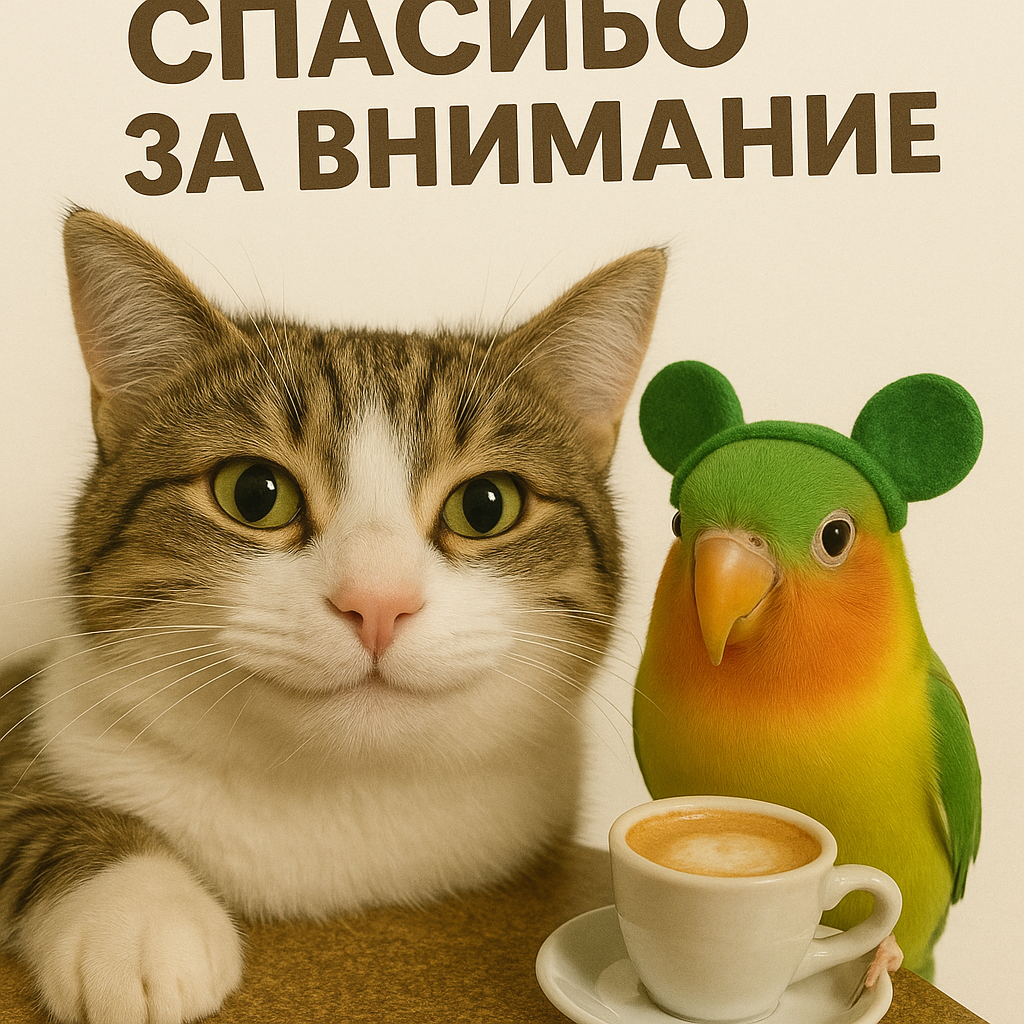